# Variational quantum eigensolver

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Gopal-Dahale/qmnp/blob/main/vqe/vqe.ipynb)


VQE is based on a parameterized quantum circuit $U(\theta)$, whose parameters are optimized such that the energy is minimized, i.e.,

$$\min_\theta E(\theta)= \min_\theta \langle 0| {U}^{\dagger}(\theta) H {U}(\theta)|0\rangle .$$

If we optimize all the way to the exact ground state energy then the quantum state at the end of the circuit $|\psi\rangle = {U}(\theta_{opt})|0\rangle$ is the exact ground state of $H$.

The parameterized quantum circuit is also often referred to as an ansatz (for the ground state in this case). Coming up with a good parameterized quantum circuit ansatz is a difficult task and often done heuristically. A common choice is the hardware-efficient ansatz which is composed of a layer of parameterized single-qubit rotations and a layer of fixed, two-qubit entangling gates.

The idea of the VQE algorithm is as follows. We have a Hamiltonian that can be expressed by the sum of tensor products of Pauli operators (Pauli terms):

$$
\hat{H} / \hbar = -\omega_I \hat{I} - \frac{\omega_X}{2} \hat{X} - \frac{\omega_Y}{2} \hat{Y} - \frac{\omega_Z}{2} \hat{Z},
$$

where $\omega_I$, $\omega_X$, $\omega_Y$, and $\omega_Z$ are all real numbers, and $\hat{X}$, $\hat{Y}$, and $\hat{Z}$ are the Pauli matrices. The minus signs are just a convention, part of the definition of the $\omega$'s.


Here are matrix representations of each Pauli operators:

$$
I = \begin{pmatrix}
1 & 0\\
0 & 1
\end{pmatrix},
\qquad
Z = \begin{pmatrix}
1 & 0\\
0 & -1
\end{pmatrix},
\qquad
X = \begin{pmatrix}
0 & 1\\
1 & 0
\end{pmatrix},
\qquad
Y = \begin{pmatrix}
0 & -i\\
i & 0
\end{pmatrix}.
$$

We chose:

$$
\hat{H} / \hbar = -\omega_I \hat{I} - \frac{\omega_X}{2} \hat{X} - \frac{\omega_Y}{2} \hat{Y} - \frac{\omega_Z}{2} \hat{Z},
$$

For a given $\left| \psi \right\rangle$ we want to measure the expectation value of the Hamiltonian:

$$\left\langle H \right\rangle = \left\langle \psi \right| H \left| \psi \right\rangle = -\omega_I \cdot \left\langle \psi \right| I \left| \psi \right\rangle -\frac{\omega_X}{2} \cdot \left\langle \psi \right| X \left| \psi \right\rangle -\frac{\omega_Y}{2} \cdot \left\langle \psi \right| Y \left| \psi \right\rangle -\frac{\omega_Z}{2} \cdot \left\langle \psi \right| Z \left| \psi \right\rangle$$

It constructs a quantum circuit for each Pauli term and computes the expectation value of the corresponding Pauli term. Then, the algorithm sums all calculated expectation values of Pauli terms and obtains the expectation value of $H$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.quantum_info import Operator, SparsePauliOp, Statevector, state_fidelity
from scipy.optimize import minimize

seed = 32
np.random.seed(seed)

In [2]:
omega = [-np.pi / 2] * 4
omega

[-1.5707963267948966,
 -1.5707963267948966,
 -1.5707963267948966,
 -1.5707963267948966]

In [3]:
H = SparsePauliOp.from_list(
    [
        ("I", omega[0]),
        ("X", omega[1] / 2),
        ("Y", omega[2] / 2),
        ("Z", omega[3] / 2),
    ]
)

H_mat = H.to_matrix()

print("Real part of H:")
print(H_mat.real)
print()

print("Imaginary part of H:")
print(H_mat.imag)

Real part of H:
[[-2.35619449 -0.78539816]
 [-0.78539816 -0.78539816]]

Imaginary part of H:
[[ 0.          0.78539816]
 [-0.78539816  0.        ]]


Find smallest eigenvalue of the given Hamiltonian with a classical algorithm. This value will be used as a reference for comparing it with the VQE result.

In [4]:
eigenvalues, eigenvectors = np.linalg.eigh(H)
gs_energy = eigenvalues[0]
gs_state = eigenvectors[:, 0]
print(f"The exact ground state energy is: {gs_energy:.4f}")

The exact ground state energy is: -2.9311


Now we need to create "good" ansatz states. First of all, note that every possible wavefunction $\left| \psi \right\rangle$ can be presented as a vector: 
$$
\left| \psi \right\rangle = \cos{\left( \theta/2 \right)} |0 \rangle + e^{i \varphi} \cdot \sin{\left( \theta/2 \right)} |1\rangle
$$

where the numbers $\theta$ and $\varphi$ define a point on the unit three-dimensional sphere that is called Bloch sphere.

<div align='center'>
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/6b/Bloch_sphere.svg/1024px-Bloch_sphere.svg.png" alt="drawing" width="300"/>
</div>

 Before quantum state preparation, our qubit is in $\left| 0 \right\rangle = \begin{pmatrix}
1\\
0
\end{pmatrix}$
state. This corresponds to the vertical position of the vector in the Bloch sphere. In order to generate any possible $\left| \psi \right\rangle$ we will apply $R_x(\theta_0)$ and $R_y(\theta_1)$ gates on the $\left| 0 \right\rangle$ initial state: 
$$\left| \psi (\boldsymbol{\theta} = (\theta_0, \theta_1)) \right\rangle =  R_y(\theta_1) R_x(\theta_0) \left| 0 \right\rangle$$. 

With these two rotations, one can have access to any point in the Bloch sphere. Here we show the matrix forms of $R_x(\theta_0)$ and $R_y(\theta_1)$ gates:

$$
R_x(\theta_0) = \begin{pmatrix}
\cos\left(\frac{\theta_0}{2}\right) & -i\sin\left(\frac{\theta_0}{2}\right)\\
-i \sin\left(\frac{\theta_0}{2}\right) & \cos\left(\frac{\theta_0}{2}\right)
\end{pmatrix},
\qquad
R_y(\theta_1) = \begin{pmatrix}
\cos\left(\frac{\theta_1}{2}\right) & -\sin\left(\frac{\theta_1}{2}\right)\\
\sin\left(\frac{\theta_1}{2}\right) & \cos\left(\frac{\theta_1}{2}\right)
\end{pmatrix}
$$

The two parameters $\theta_0, \theta_1$ will be in control of the Classical Computer and its optimization model. Here is the corresponding circuit:

<div align='center'>
    <img src="arch.png" width=900 />
</div>

image source: https://arxiv.org/pdf/1304.3061

Note that in the general case if we know for some reason that $\left| \psi_g \right\rangle$ is in the $M$ subspace of the Hilbert space, we will not need to create a parameterized circuit that will have access to all possible states in the Hilbert space. It will be sufficient to have an ansatz circuit that will be able to create all quantum states in the $M$ subspace. 

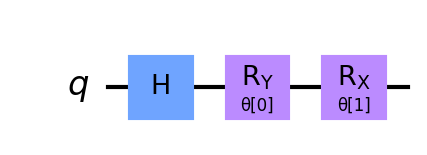

In [5]:
theta = ParameterVector("θ", 2)
ansatz = QuantumCircuit(1)
ansatz.h(0)
ansatz.ry(theta[0], 0)
ansatz.rx(theta[1], 0)
ansatz.draw("mpl", style="clifford", scale=1.5)

Now we come to the part of the algorithm where we should do individual/separate measurements of expectation values of the Pauli terms. For one qubit case, there are only four possible Pauli terms: 4 basic Pauli operators $I$, $X$, $Y$, $Z$.

$$\left\langle H \right\rangle = \left\langle \psi \right| H \left| \psi \right\rangle = -\frac{\omega_I}{2} \cdot \left\langle \psi \right| I \left| \psi \right\rangle -\frac{\omega_X}{2} \cdot \left\langle \psi \right| X \left| \psi \right\rangle -\frac{\omega_Y}{2} \cdot \left\langle \psi \right| Y \left| \psi \right\rangle -\frac{\omega_Z}{2} \cdot \left\langle \psi \right| Z \left| \psi \right\rangle$$

For $I$ operator the  expectation value is always unity: $\left\langle \psi \right| I \left| \psi \right\rangle = \left\langle \psi \right| \left| \psi \right\rangle = 1$. So, its contribution to the overall expectation value $\left\langle H \right\rangle$ will be equal to $-\omega_I / 2$.

## Change of Basis
We need to compute the expectation values of a general quantum state $|\psi\rangle$ in the $X$, $Y$, and $Z$ bases:

**Expectation Value in the $Z$-basis:**

Since the state $|\psi\rangle$ is given in the $Z$-basis, we can directly measure $Z$ without any basis change. To measure the expectation value of $Z$, take repeated measurements (shots) in the $Z$-basis. Count the occurrences of $|0\rangle$ (which has $Z = +1$) and $|1\rangle$ (which has $Z = -1$).
   
$$
\langle Z \rangle = \frac{N_0 - N_1}{N}
$$

**Measurement in X basis:**

$$
\langle X \rangle = \frac{N_{+} - N_{-}}{N}
$$

Here $N_+$ and $N_-$ are numbers of measurements in X basis that corresponds to $\left| + \right\rangle$ or $\left| - \right\rangle$ outcomes respectively. We still do a $Z$ basis measurement, but, before that, we apply specific operators to the $\left| \psi \right\rangle$ state. We try to apply such an operator that after measuring, the probability of $\left| 0 \right\rangle$ outcome will be equal to the probability of $\left| + \right\rangle$ outcome and the probability of $\left| 1 \right\rangle$ outcome will be equal to the probability of $\left| - \right\rangle$.

To measure in the $X$-basis, apply a **Hadamard gate** $H$ before measurement. The Hadamard gate transforms the $Z$-basis states as follows:

$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \quad H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$
   
After applying the Hadamard gate, a measurement in the $Z$-basis corresponds to measuring in the $X$-basis before the gate was applied.


**Measurement in X basis:**

$$
\langle Y \rangle = \frac{N_{+i} - N_{-i}}{N}
$$

Here $N_{+i}$ and $N_{-i}$ are numbers of measurements in Y basis that corresponds to $\left| +i \right\rangle$ or $\left| -i \right\rangle$ outcomes respectively. Similar to X basis, we apply an operator that transforms $\left| 0 \right\rangle \rightarrow \left| +i \right\rangle$ and $\left| 1 \right\rangle \rightarrow \left| -i \right\rangle$.

To measure in the $Y$-basis, apply a **$S^\dagger$ (inverse phase) gate followed by a Hadamard gate** before measurement. These gates transform the $Z$-basis states as follows:

$$
H S^\dagger |0\rangle = \frac{|0\rangle + i |1\rangle}{\sqrt{2}}, \quad H S^\dagger |1\rangle = \frac{|0\rangle - i |1\rangle}{\sqrt{2}}
$$
   
After applying $S^\dagger H$, a measurement in the $Z$-basis corresponds to measuring in the $Y$-basis.

We need to make circuits that perform the needed post-rotations needed for the measurements defined by the op_strings. We need a function to do this. The below function `opstr_to_meas_circ` takes a list of operator strings and makes circuit with the correct post-rotations for measurements.

In [6]:
def opstr_to_meas_circ(op_str):
    num_qubits = len(op_str[0])
    circs = []
    for op in op_str:
        qc = QuantumCircuit(num_qubits)
        for idx, item in enumerate(op):
            if item == "X":
                qc.h(num_qubits - idx - 1)
            elif item == "Y":
                qc.sdg(num_qubits - idx - 1)
                qc.h(num_qubits - idx - 1)
        circs.append(qc)
    return circs

Next we actual grab the measurement circuits

Measurement circuit for Pauli - I


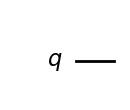


Measurement circuit for Pauli - X


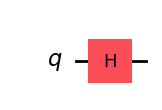


Measurement circuit for Pauli - Y


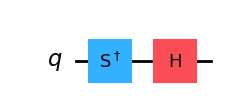


Measurement circuit for Pauli - Z


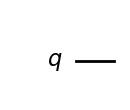

In [7]:
op_strings = H.paulis.to_labels()
meas_circs = opstr_to_meas_circ(op_strings)

for op_str, circ in zip(op_strings, meas_circs):
    print(f"Measurement circuit for Pauli - {op_str}")
    display(circ.draw("mpl"))
    print()

Having both the ansatz and measurement circuits in hand we can now combine them and add measurements.

Full circuit for Pauli - I


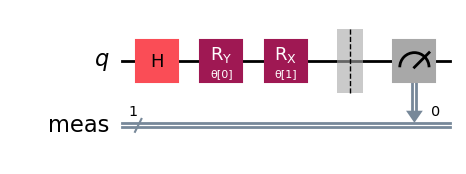


Full circuit for Pauli - X


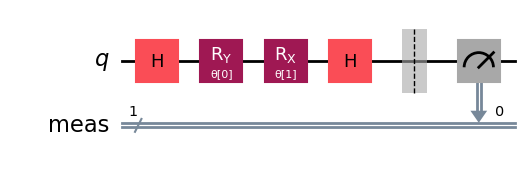


Full circuit for Pauli - Y


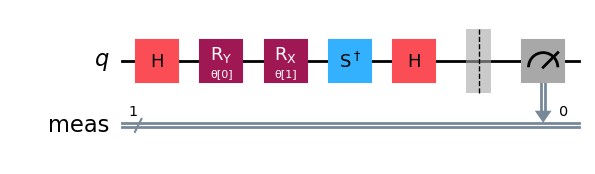


Full circuit for Pauli - Z


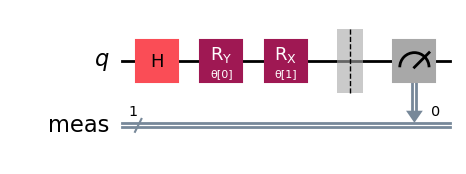

In [8]:
def get_full_circs(base_circuit, op_strings, meas_circs, verbose=False):
    full_circs = []
    for op_str, circ in zip(op_strings, meas_circs):
        new_circ = base_circuit.compose(circ).measure_all(inplace=False)
        full_circs.append(new_circ)

        if verbose:
            print(f"Full circuit for Pauli - {op_str}")
            display(new_circ.draw("mpl"))
            print()
    return full_circs


full_circs = get_full_circs(ansatz, op_strings, meas_circs, True)

Lastly, we need the strings that will tell the expectation value function which diagonal operators to use. Because we have added post-rotations to each circuit for the X and Y measurements, these strings need to be converted to Z:

In [9]:
def get_rotated_hamiltonian(ham):
    H_rotated_list = []
    for op, coeff in ham.to_list():
        rotated_op = op.replace("X", "Z").replace("Y", "Z")
        H_rotated_list.append((rotated_op, coeff))

    H_rotated = SparsePauliOp.from_list(H_rotated_list)
    return H_rotated


H_rotated = get_rotated_hamiltonian(H)
H_rotated

SparsePauliOp(['I', 'Z', 'Z', 'Z'],
              coeffs=[-1.57079633+0.j, -0.78539816+0.j, -0.78539816+0.j, -0.78539816+0.j])

## Calculation of Expectation Value from Samples

Given a observable that is diagonal in the $Z$-basis: $\hat{O} = \sum_\mathbf{z} f(\mathbf{z}) |\mathbf{z}\rangle\langle \mathbf{z}|$ with possible measurement outcomes $f(\mathbf{z})$, the expectation value $\langle \psi |\hat{O}|\psi\rangle$ can be estimated as

$$ \langle \psi |\hat{O}|\psi\rangle \sim \frac{1}{M_s} \sum_{i=1}^{M_s} f(\mathbf{z}^{(i)}) ,$$

where $M_s$ is the number of measurements (shots) and $f(\mathbf{z}^{(i)})$ is the measurement outcome for the ith measurement.

As an example, if you measure the j-th qubit on the quantum device, $\hat{Z}_j = \sum_\mathbf{z} (-1)^{z_j} |\mathbf{z}\rangle\langle \mathbf{z}|$, so $f(\mathbf{z})=(-1)^{z_j}$.

(Note that in Qiskit 0 corresponds to eigenvalue +1 (spin up) and 1 to eigenvalue -1 (spin down).)


The function used to actually compute the cost function (energy) is given as:

In [10]:
def vqe_func(params, circuits, hamiltonian, sampler, n_shots=1024):

    pubs = []  # primitive unified blocs (Qiskit's naming convention)
    for circ in circuits:
        pubs.append((circ, params))
    results = sampler.run(pubs, shots=n_shots).result()

    expvals = []
    for result, (op, coeff) in zip(results, H_rotated.to_list()):
        counts = result.data.meas.get_counts()

        z_indices = []
        for idx, pauli in enumerate(op):
            if pauli == "Z":
                z_indices.append(idx)

        expval = 0
        for bitstring, count in counts.items():
            bits = np.array([int(bit) for bit in bitstring])
            szs = (-1) ** (sum(bits[z_indices]))
            expval += szs * count / n_shots

        expvals.append(expval * coeff)

    energy = sum(expvals).real
    return energy

We now need to set the starting point of the VQE iterations. This means selecting a set of initial parameters to pass to the parameterized circuits. Here we select ones close to a solution vector:

In [11]:
np.random.seed(seed)
num_params = ansatz.num_parameters
params = np.random.random(num_params)
params = np.ones(num_params) * np.pi / 4 * 0
params

array([0., 0.])

In [12]:
sampler = Sampler(seed=seed)
vqe_func(params, full_circs, H_rotated, sampler)

-2.3439226438892593

Finally, we can now execute the VQE function using one of the solvers from SciPy, returning the solution for the minimum energy and the associated parameters:

In [13]:
temp = []


def fun(x):
    temp.append(x)

In [14]:
res = minimize(
    vqe_func,
    params,
    (full_circs, H_rotated, sampler),
    method="COBYLA",
    options={"maxiter": 20},
    callback=fun,
)

In [15]:
def rel_err(target, measured):
    return abs((target - measured) / target)

In [16]:
print(f"Exact ground state energy: {gs_energy:.4f}")
print(f"Ground state energy from VQE: {res.fun:.4f}")
print(f"Relative Error: {rel_err(gs_energy, res.fun):.4f}")

Exact ground state energy: -2.9311
Ground state energy from VQE: -2.8916
Relative Error: 0.0135


In [17]:
y_vals = np.array([vqe_func(x, full_circs, H_rotated, sampler) for x in temp])
x_vals = range(len(y_vals))

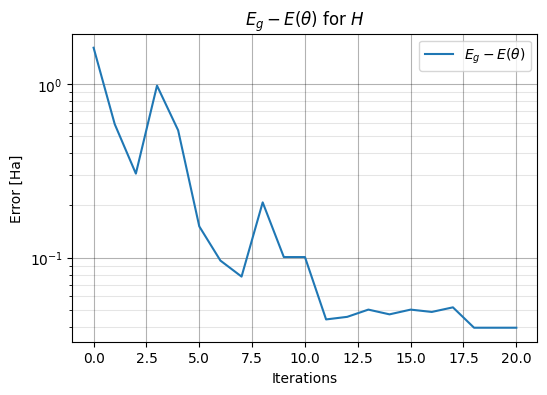

In [18]:
fig = plt.figure(figsize=(6, 4))
plt.plot(x_vals, np.abs(y_vals - gs_energy), label=r"$E_g - E(\theta)$")
plt.xlabel("Iterations")
plt.ylabel("Error [Ha]")
plt.yscale("log")
plt.grid(which="major", color="black", linestyle="-", alpha=0.3)
plt.grid(which="minor", color="black", linestyle="-", alpha=0.1)
plt.legend()
plt.title(r"$E_g - E(\theta)$ for $H$")
plt.savefig("error_curve.png")
plt.show()

In [19]:
# animate (only possible if have access to statevector)

# get svs
svs = []
for x in temp:
    sv = Statevector(ansatz.assign_parameters(x))
    svs.append(sv)

# convert to qutip object
import qutip

states = []
for sv in svs:
    states.append(sv[0] * qutip.basis(2, 0) + sv[1] * qutip.basis(2, 1))

In [20]:
import imageio


def animate_bloch(states, ref_state, duration=0.1, save_all=False):

    b = qutip.Bloch()
    b.vector_color = ["b"]
    images = []
    try:
        length = len(states)
    except:
        length = 1
        states = [states]

    ## customize sphere properties ##
    b.point_marker = ["o"]
    b.point_size = [20]

    for i in range(length):
        b.clear()
        b.add_states(ref_state)
        b.add_states(states[i])
        b.add_states(states[: (i + 1)], "point", colors=["b"] * len(states[: (i + 1)]))
        if save_all:
            b.save(dirc="tmp")  # saving images to tmp directory
            filename = "tmp/bloch_%01d.png" % i
        else:
            filename = "temp_file.png"
            b.save(filename)
        images.append(imageio.v2.imread(filename))
    imageio.mimsave("bloch_anim.gif", images, loop=0, duration=duration)

In [21]:
ref_state = gs_state[0] * qutip.basis(2, 0) + gs_state[1] * qutip.basis(2, 1)
animate_bloch(states, ref_state, duration=0.1, save_all=False)

Below is an animation which shows statevectors during the optimization process. If not rendered, can be seen by clicking [here](https://github.com/Gopal-Dahale/qmnp/tree/main/vqe#1-qubit-animation)

<img src='bloch_anim.gif'/>

## Fidelity

$$
F(\psi, \phi) = |\langle \psi | \phi \rangle|^2
$$

In [22]:
state_fidelity(Statevector(gs_state), svs[-1])

0.9973423163675967

## Energy Landscape

In [23]:
import time

from matplotlib.ticker import FormatStrFormatter, LinearLocator


def generate_surface():
    Z = []
    Z_assembler = []

    global interval, xlow, ylow

    X = np.arange(xlow[0], xlow[1], interval)
    Y = np.arange(ylow[0], ylow[1], interval)
    X, Y = np.meshgrid(X, Y)
    params = []

    start = time.time()
    for x in X[0, :]:
        for y in Y[:, 0]:
            rotations = np.array([x, y])
            Z_assembler.append(vqe_func(rotations, full_circs, H_rotated, sampler))
        Z.append(Z_assembler)
        Z_assembler = []
    Z = np.array(Z)
    end = time.time()
    print(f"Duration: {end-start:.4f}, ", end=" ")

    return Z

In [24]:
interval = 0.5
xlow = [-np.pi, np.pi]
ylow = [-np.pi, np.pi]
surface = generate_surface()

Duration: 1.7868,  

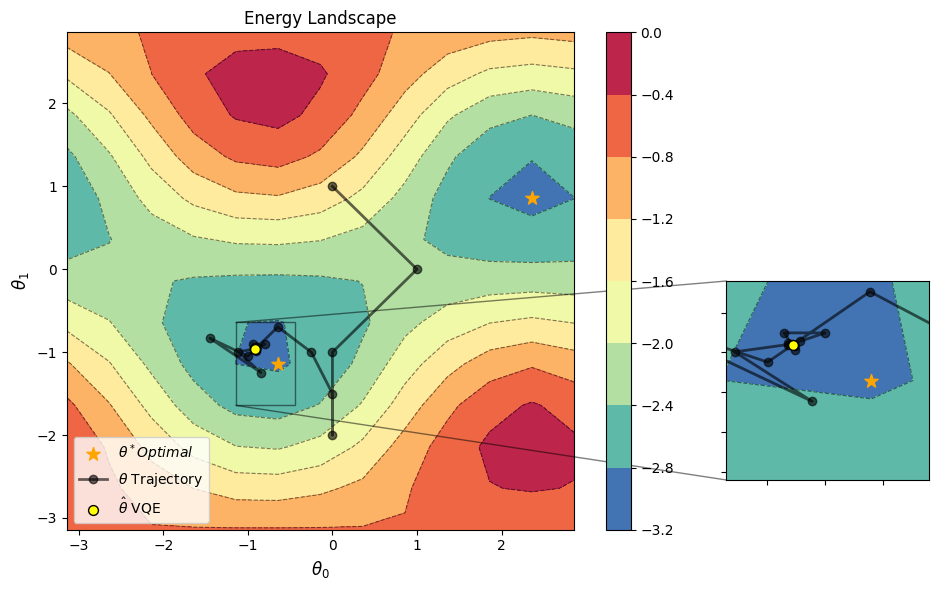

In [31]:
from mpl_toolkits.axes_grid1.inset_locator import (
    inset_axes,
    mark_inset,
    zoomed_inset_axes,
)

X = np.arange(xlow[0], xlow[1], interval)
Y = np.arange(ylow[0], ylow[1], interval)
X, Y = np.meshgrid(X, Y)

fig, ax = plt.subplots(figsize=(10, 6))

CS = ax.contourf(X, Y, surface, cmap="Spectral_r")

# Dotted contour lines for the curvature
contour_lines = ax.contour(
    CS, colors="black", linestyles="dashed", linewidths=0.8, alpha=0.5
)
plt.xlabel(r"$\theta_0$", fontsize=12)
plt.ylabel(r"$\theta_1$", fontsize=12)

num_min = 2
min_indices = np.argsort(surface.flatten())[:num_min]
min_indices = [np.unravel_index(idx, surface.shape) for idx in min_indices]
min_t1 = [np.arange(xlow[0], xlow[1], interval)[idx[1]] for idx in min_indices]
min_t0 = [np.arange(ylow[0], ylow[1], interval)[idx[0]] for idx in min_indices]
min_values = [surface[idx] for idx in min_indices]
ax.scatter(
    min_t1,
    min_t0,
    color="orange",
    s=100,
    zorder=100,
    marker="*",
    label=r"$\theta^* Optimal$",
)
# for i, (idx, g, b,val) in enumerate(zip(min_indices,min_t1, min_t0,min_values)):
#     ax.text(g, b + 0.1, f"{val:.2f}", color='white', fontsize=12)
plt.colorbar(CS)

x_store = np.array(temp)
ax.plot(
    x_store[:, 1],
    x_store[:, 0],
    lw=2,
    c="k",
    marker="o",
    alpha=0.6,
    label=r"$\theta$ Trajectory",
)
ax.scatter(
    x_store[-1, 1],
    x_store[-1, 0],
    s=50,
    c="yellow",
    edgecolor="k",
    zorder=200,
    marker="o",
    label=r"$\hat \theta$ VQE",
)

# axins.contourf(x, y, z, cmap="YlGnBu_r")

zoom_width = 0.4  # Size of the zoomed region (relative to the main plot)
zoom_height = 0.4
x_center = min_t1[1]  # Center around the minimum value for theta1
y_center = min_t0[1]  # Center around the minimum value for theta0
axin = ax.inset_axes(
    [1.3, 0.1, zoom_width, zoom_height],  # Place it in the lower-left
    xlim=[x_center - 0.5, x_center + 0.2],
    ylim=[y_center - 0.5, y_center + 0.5],
    xticklabels=[],
    yticklabels=[],
)

axin.contourf(X, Y, surface, cmap="Spectral_r")
axin.contour(CS, colors="black", linestyles="dashed", linewidths=0.8, alpha=0.5)
axin.plot(x_store[:, 1], x_store[:, 0], lw=2, c="black", alpha=0.6, marker="o")
axin.scatter(min_t1, min_t0, color="orange", s=100, zorder=100, marker="*")
axin.scatter(
    x_store[-1, 1],
    x_store[-1, 0],
    s=50,
    edgecolor="k",
    c="yellow",
    zorder=200,
    marker="o",
)
ax.indicate_inset_zoom(axin, edgecolor="black")

ax.legend(loc="lower left")
plt.title("Energy Landscape")
filename = "energy_landscape.png"
plt.tight_layout()
if filename:
    plt.savefig(filename)
plt.show()

## Real quick: H$_2$ molecule

In [36]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper

driver = PySCFDriver(atom="H 0 0 0; H 0 0 0.735")
problem = driver.run()

fermionic_op = problem.hamiltonian.second_q_op()

mapper = JordanWignerMapper()
qubit_op = mapper.map(fermionic_op)
print(qubit_op)

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.12091263+0.j,
  0.17218393+0.j,  0.16892754+0.j, -0.22575349+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])


In [42]:
for i, j in qubit_op.to_list():
    print(i, np.around(j.real,2))

IIII -0.81
IIIZ 0.17
IIZI -0.23
IIZZ 0.12
IZII 0.17
IZIZ 0.17
ZIII -0.23
ZIIZ 0.17
YYYY 0.05
XXYY 0.05
YYXX 0.05
XXXX 0.05
IZZI 0.17
ZIZI 0.17
ZZII 0.12


In [27]:
print("Number of qubits:", qubit_op.num_qubits)
print("Number of Hamiltonian terms:", len(qubit_op))

Number of qubits: 4
Number of Hamiltonian terms: 15


In [28]:
eigenvalues, eigenvectors = np.linalg.eigh(qubit_op.to_matrix())
gs_energy = eigenvalues[0]
gs_state = eigenvectors[:, 0]
print(f"The exact ground state energy is: {gs_energy:.4f}")

The exact ground state energy is: -1.8573


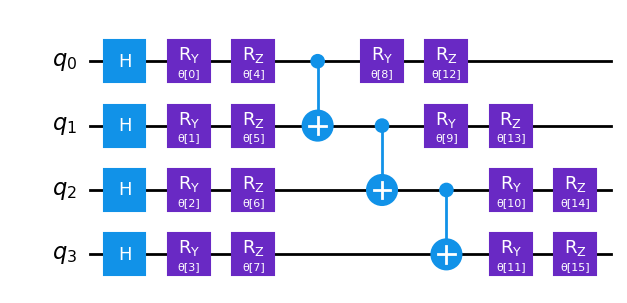

In [29]:
ansatz = QuantumCircuit(qubit_op.num_qubits)
ansatz.h(range(qubit_op.num_qubits))
ansatz.compose(TwoLocal(
    num_qubits=qubit_op.num_qubits,
    rotation_blocks=["ry", "rz"],
    entanglement_blocks=["cx"],
    entanglement="linear",
    reps=1,
).decompose(), range(4), inplace=True)
ansatz.draw("mpl", style="textbook")

In [30]:
op_strings = qubit_op.paulis.to_labels()
meas_circs = opstr_to_meas_circ(op_strings)
full_circs = get_full_circs(ansatz, op_strings, meas_circs, False)

H_rotated = get_rotated_hamiltonian(qubit_op)
H_rotated

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'ZZZZ', 'ZZZZ', 'ZZZZ', 'ZZZZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.12091263+0.j,
  0.17218393+0.j,  0.16892754+0.j, -0.22575349+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])

In [31]:
np.random.seed(seed)
num_params = ansatz.num_parameters
params = np.random.random(num_params)

temp = []

res = minimize(
    vqe_func,
    params,
    (full_circs, H_rotated, sampler),
    method="COBYLA",
    options={"maxiter": 300},
    callback=fun,
)

In [32]:
print(f"Exact ground state energy: {gs_energy:.4f}")
print(f"Ground state energy from VQE: {res.fun:.4f}")
print(f"Relative Error: {rel_err(gs_energy, res.fun):.4f}")

Exact ground state energy: -1.8573
Ground state energy from VQE: -1.8536
Relative Error: 0.0020


In [33]:
y_vals = np.array([vqe_func(x, full_circs, H_rotated, sampler) for x in temp])
x_vals = range(len(y_vals))

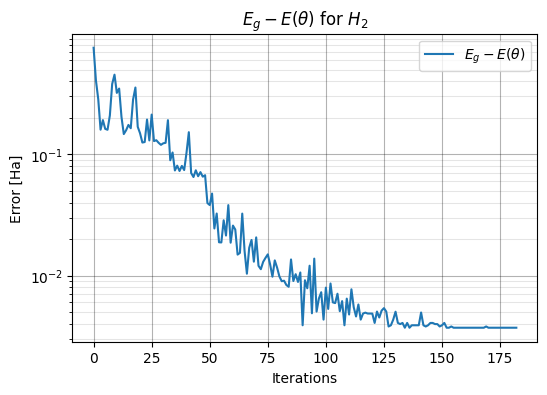

In [34]:
fig = plt.figure(figsize=(6, 4))
plt.plot(x_vals, np.abs(y_vals - gs_energy), label=r"$E_g - E(\theta)$")
plt.xlabel("Iterations")
plt.ylabel("Error [Ha]")
plt.yscale("log")
plt.grid(which="major", color="black", linestyle="-", alpha=0.3)
plt.grid(which="minor", color="black", linestyle="-", alpha=0.1)
plt.legend()
plt.title(r"$E_g - E(\theta)$ for $H_2$")
plt.savefig("error_curve_h2.png")
plt.show()

## Glossary
- Chemical accuracy represents the level of precision required to make realistic chemical predictions, generally considered as errors below 1 kcal/mole (Hartree/particle) with respect to the total energy ([cite](https://journals.aps.org/rmp/pdf/10.1103/RevModPhys.71.1267))
- A hartree is a unit of energy used in molecular orbital calculations. A hartree is equal to 2625.5 kJ/mol, 627.5 kcal/mol, 27.211 eV, and 219474.6 cm-1.

## Appendix

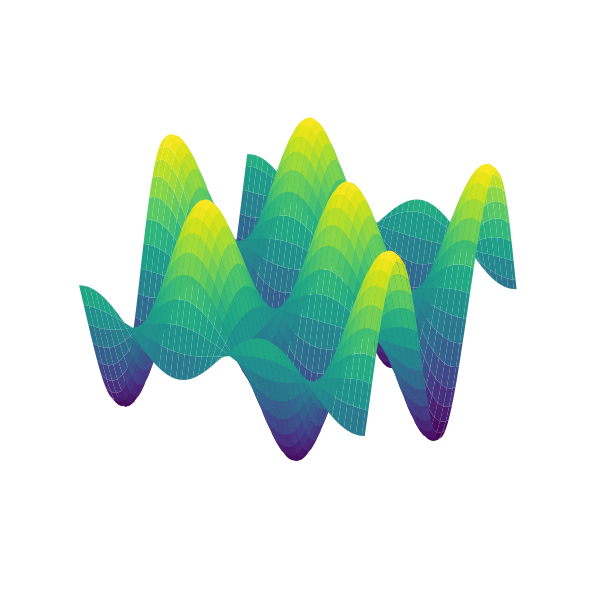

In [35]:
# Importing necessary libraries to create a 3D surface plot similar to the uploaded image.
import matplotlib.pyplot as plt
import numpy as np

# Setting up the grid and function for the 3D surface plot.
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X)*np.cos(Y)

# Creating the 3D surface plot.
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# Hiding the axes for a cleaner look.
ax.set_axis_off()

# Displaying the plot.
plt.tight_layout()
plt.savefig('optimizer.png')
plt.show()

## Points to ponder

- We used gradient-free optimization. How can we compute gradients of the expectation value w.r.t the parameters?
- What is good ansatz? See [this](https://arxiv.org/pdf/1905.10876) paper on Expressibility of ansatzes.


<h3 align="left">
References
</h3>

[[1]] [A. Peruzzo et al., Nature Communications, "A variational eigenvalue solver on a photonic quantum processor" (2014).][1]

[[2]] [Michał Stęchły, "Variational Quantum Eigensolver explained"][2].

[[3]] [M.A. Nielsen, I.L. Chuang, Cambridge University Press New York, "Quantum Computation and Quantum Information: 10th Anniversary Edition
10th" (2011)][3]

[[4]] [Learn Quantum Computation using Qiskit: Simulating Molecules using VQE][4]

  [1]: https://www.nature.com/articles/ncomms5213?origin=ppub
  [2]: https://www.mustythoughts.com/variational-quantum-eigensolver-explained
  [3]: https://www.cambridge.org/am/academic/subjects/physics/quantum-physics-quantum-information-and-quantum-computation/quantum-computation-and-quantum-information-10th-anniversary-edition?format=HB
  [4]: https://qiskit.org/textbook/ch-applications/vqe-molecules.html
  [5]: https://github.com/DavitKhach/quantum-algorithms-tutorials/blob/master/iterative_quantum_phase_estimation.ipynb
  [6]: https://github.com/DavitKhach/quantum-algorithms-tutorials/blob/master/quantum_phase_estimation.ipynb
  [7]: https://github.com/DavitKhach/quantum-algorithms-tutorials
  [8]: https://nbviewer.jupyter.org/github/DavitKhach/quantum-algorithms-tutorials/blob/master/variational_quantum_eigensolver.ipynb